In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

**DATASET UPLOAD**

In [4]:
dataset = pd.read_csv("/content/Customer-Churn-Records.csv")

**DATA CLEANING**

In [5]:
print(dataset.info()) #Dimentionality
print(dataset.duplicated().sum()) #Duplicates
print(dataset.isnull().sum()) #Null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

**FEATURE SELECTION**

In [6]:
features = [
    "CreditScore",
    "Geography",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary",
    "Card Type"
]

segmentation_data = dataset[features].copy()

**EXPLORATORY DATA ANALYSIS**

In [11]:
numeric_features = [ #Divide between numeral feature and categorical features we will use
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "EstimatedSalary"
]

categorical_features = [
    "Geography",
    "HasCrCard",
    "IsActiveMember",
    "NumOfProducts",
    "Card Type"
]

In [12]:
print(segmentation_data[numeric_features].describe()) #summary statistics for the numerical features

        CreditScore           Age        Tenure        Balance  \
count  10000.000000  10000.000000  10000.000000   10000.000000   
mean     650.528800     38.921800      5.012800   76485.889288   
std       96.653299     10.487806      2.892174   62397.405202   
min      350.000000     18.000000      0.000000       0.000000   
25%      584.000000     32.000000      3.000000       0.000000   
50%      652.000000     37.000000      5.000000   97198.540000   
75%      718.000000     44.000000      7.000000  127644.240000   
max      850.000000     92.000000     10.000000  250898.090000   

       EstimatedSalary  
count     10000.000000  
mean     100090.239881  
std       57510.492818  
min          11.580000  
25%       51002.110000  
50%      100193.915000  
75%      149388.247500  
max      199992.480000  


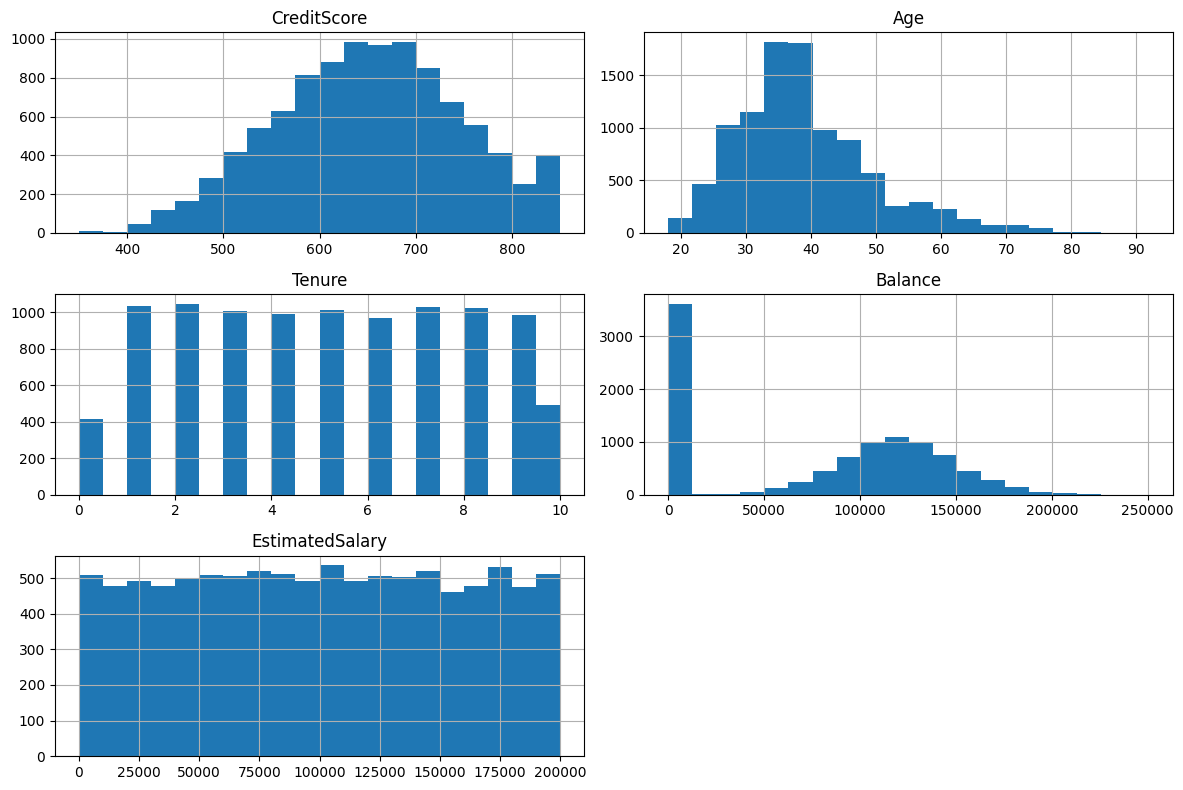

In [13]:
segmentation_data[numeric_features].hist(
    figsize=(12, 8),
    bins=20
)

plt.tight_layout()
plt.show()


Geography
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


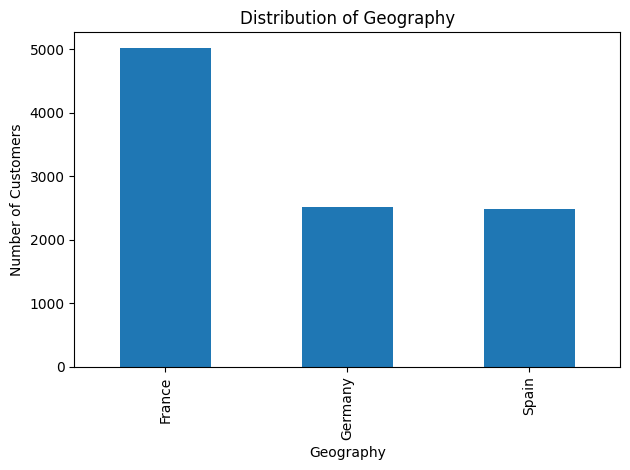


HasCrCard
HasCrCard
1    7055
0    2945
Name: count, dtype: int64


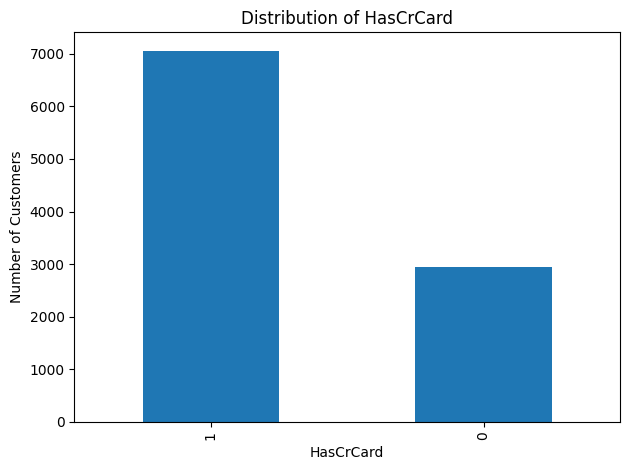


IsActiveMember
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64


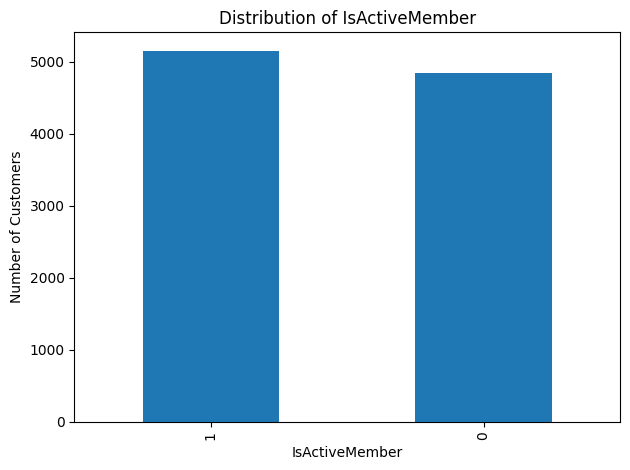


NumOfProducts
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


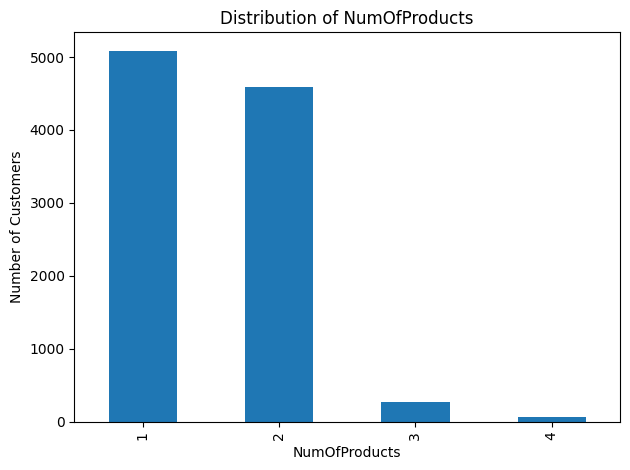


Card Type
Card Type
DIAMOND     2507
GOLD        2502
SILVER      2496
PLATINUM    2495
Name: count, dtype: int64


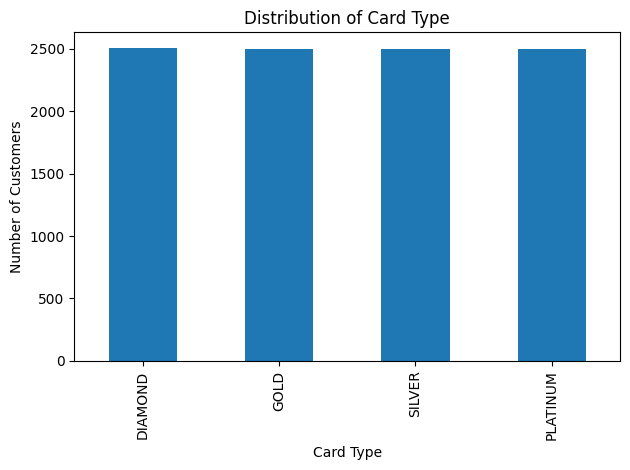

In [14]:
for feature in categorical_features: #analysis for the categorical variables
    print(f"\n{feature}")
    print(segmentation_data[feature].value_counts())

    segmentation_data[feature].value_counts().plot(
        kind="bar",
        title=f"Distribution of {feature}"
    )

    plt.ylabel("Number of Customers")
    plt.tight_layout()
    plt.show()

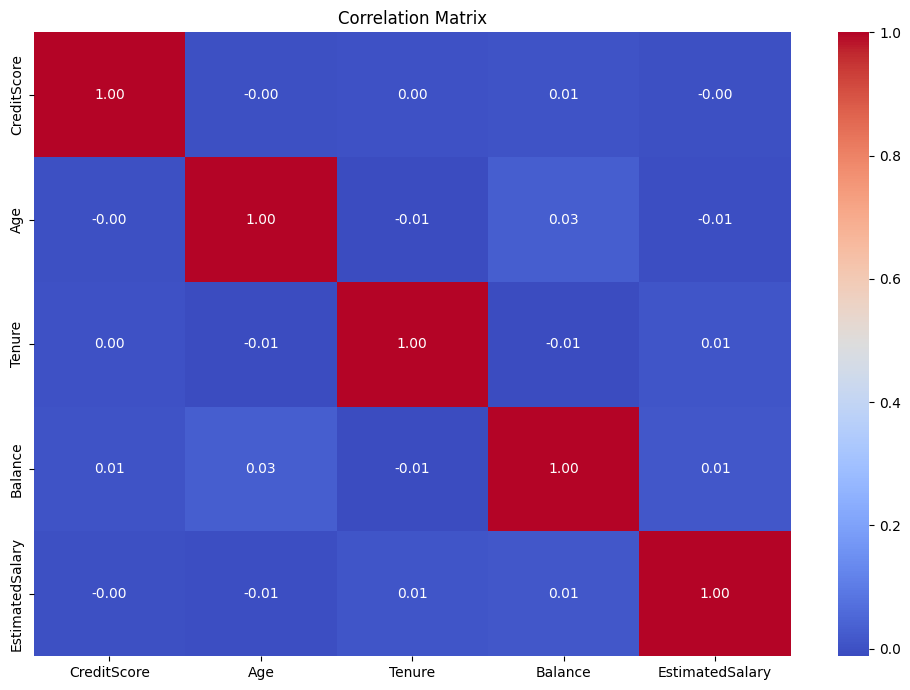

In [16]:
correlation_matrix = segmentation_data[numeric_features].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

**DATA SCALING AND ONE-HOT ENCODING**

In [21]:
encoder = OneHotEncoder(sparse_output=False, drop="first") #one-hot encoding for cat variables

categorical_encoded = encoder.fit_transform(
    segmentation_data[categorical_features]
)

In [20]:
#scaling for numerical
scaler = StandardScaler()

numeric_scaled = scaler.fit_transform(
    segmentation_data[numeric_features]
)

In [24]:
X = np.hstack([
    numeric_scaled,
    categorical_encoded
]) #dataset that has one-hot encoding and scaling

**CHOOSING K**

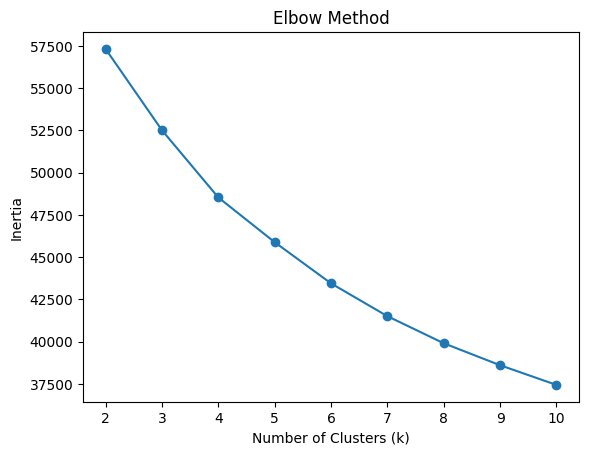

In [26]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

**K-MEANS**

In [27]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)

segmentation_data["Cluster"] = clusters

In [28]:
print(segmentation_data["Cluster"].value_counts().sort_index())

Cluster
0    2710
1    3298
2    1271
3    2721
Name: count, dtype: int64


In [29]:
cluster_profile = segmentation_data.groupby("Cluster")[numeric_features].mean()

print(cluster_profile.round(2))

         CreditScore    Age  Tenure    Balance  EstimatedSalary
Cluster                                                        
0             650.35  36.38    7.55  122185.61        107122.96
1             648.76  35.69    5.10    1118.93         99475.20
2             647.85  59.21    4.90   79660.23         94277.47
3             654.11  35.88    2.43  120837.02         96546.61


In [30]:
print(
    pd.crosstab(
        segmentation_data["Cluster"],
        segmentation_data["Geography"],
        normalize="index"
    ).round(3) * 100
)

Geography  France  Germany  Spain
Cluster                          
0            40.3     39.4   20.3
1            66.5      0.2   33.3
2            47.0     27.9   25.1
3            41.5     39.7   18.8


In [32]:
print(
    pd.crosstab(
        segmentation_data["Cluster"],
        segmentation_data["Card Type"],
        normalize="index"
    ).round(3) * 100
)

Card Type  DIAMOND  GOLD  PLATINUM  SILVER
Cluster                                   
0             25.6  25.6      22.9    25.9
1             23.8  24.5      25.7    26.0
2             25.7  25.7      25.3    23.2
3             25.8  24.7      25.8    23.6


In [33]:
print(
    pd.crosstab(
        segmentation_data["Cluster"],
        segmentation_data["NumOfProducts"],
        normalize="index"
    ).round(3) * 100
)

NumOfProducts     1     2    3    4
Cluster                            
0              65.5  31.3  2.4  0.8
1              23.8  73.5  2.4  0.3
2              60.7  33.0  5.1  1.1
3              64.4  33.0  2.2  0.5


In [34]:
print(
    pd.crosstab(
        segmentation_data["Cluster"],
        segmentation_data["IsActiveMember"],
        normalize="index"
    ).round(3) * 100
)

IsActiveMember     0     1
Cluster                   
0               53.5  46.5
1               50.8  49.2
2               31.9  68.1
3               48.4  51.6


In [35]:
print(
    pd.crosstab(
        segmentation_data["Cluster"],
        segmentation_data["HasCrCard"],
        normalize="index"
    ).round(3) * 100
)

HasCrCard     0     1
Cluster              
0          28.6  71.4
1          28.6  71.4
2          31.2  68.8
3          30.5  69.5


In [36]:
cluster_summary = segmentation_data.groupby("Cluster").agg({
    "Age": "mean",
    "CreditScore": "mean",
    "Balance": "mean",
    "EstimatedSalary": "mean",
    "Tenure": "mean",
    "NumOfProducts": "mean",
    "HasCrCard": "mean",
    "IsActiveMember": "mean",
    "Cluster": "count"
})

cluster_summary = cluster_summary.rename(
    columns={"Cluster": "Customer_Count"}
)

print(cluster_summary.round(2))

           Age  CreditScore    Balance  EstimatedSalary  Tenure  \
Cluster                                                           
0        36.38       650.35  122185.61        107122.96    7.55   
1        35.69       648.76    1118.93         99475.20    5.10   
2        59.21       647.85   79660.23         94277.47    4.90   
3        35.88       654.11  120837.02         96546.61    2.43   

         NumOfProducts  HasCrCard  IsActiveMember  Customer_Count  
Cluster                                                            
0                 1.38       0.71            0.46            2710  
1                 1.79       0.71            0.49            3298  
2                 1.47       0.69            0.68            1271  
3                 1.39       0.70            0.52            2721  
